<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Rossman_sales_forecasting_using_prophet_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Rossmann Store Sales**

Test challenge


Goal: Explore data and predict 6 weeks of daily sales for 1,115 stores located across Germany.

* Explore the data (ECDF, handle missing
values etc)
* Analysis per store type and correlational analysis of stores activity.
* Perform extensive Time Series Analysis (seasonal decomposition, trends, autocorrelation).
* Predict next 6 weeks of sales using Prophet (Facebook methodology)



#####import libraries

In [1]:
#!pip install prophet

In [2]:
#ignore warnings
import warnings
warnings.filterwarnings('ignore')

#basic libraries
import numpy as np
import pandas as pd
import datetime

#visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#statistics
from statsmodels.distributions.empirical_distribution import ECDF

#timeseries analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
#prophet by Facebook
from prophet import Prophet

#machine learning:XGB
import xgboost as xgb
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from xgboost.sklearn import XGBRegressor #Wrapper

##### Load and read data

In [4]:
train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kaggle_rossman/train.csv",parse_dates= True,index_col= "Date")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kaggle_rossman/test.csv")
#additional_data
store = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kaggle_rossman/store.csv")

In [5]:
train.head(10)

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1
2015-07-31,6,5,5651,589,1,1,0,1
2015-07-31,7,5,15344,1414,1,1,0,1
2015-07-31,8,5,8492,833,1,1,0,1
2015-07-31,9,5,8565,687,1,1,0,1


In [6]:
print(f"Shape         : {train.shape}")
print(f"Date range    : {train.index.min()} → {train.index.max()}")
print(f"Missing hours : {train.isnull().sum().values[0]}")
print(f"\nSample rows:")
train.tail(5)

Shape         : (1017209, 8)
Date range    : 2013-01-01 00:00:00 → 2015-07-31 00:00:00
Missing hours : 0

Sample rows:


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2013-01-01,1111,2,0,0,0,0,a,1
2013-01-01,1112,2,0,0,0,0,a,1
2013-01-01,1113,2,0,0,0,0,a,1
2013-01-01,1114,2,0,0,0,0,a,1
2013-01-01,1115,2,0,0,0,0,a,1


#####Exploratory Data Analysis

train and store data, handle missing values and create new features for further analysis.
**Column information:**
* Sales - the turnover for any given day (this is what we are predicting)
* Customers - the number of customers on a given day
* Open - an indicator for whether the store was open: 0 = closed, 1 = open
* Promo - indicates whether a store is running a promo on that day.
* StateHoliday - indicates a state holiday.

  (Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None)
* SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools



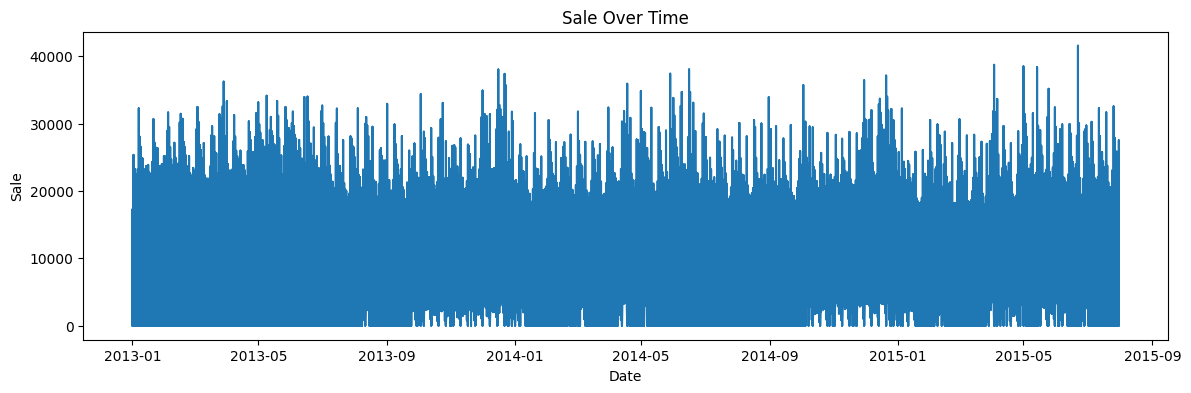

In [7]:
# =========================
# TIME SERIES PLOT
# =========================

plt.figure(figsize=(14, 4))
plt.plot(train.index, train["Sales"])
plt.title("Sale Over Time")
plt.xlabel("Date")
plt.ylabel("Sale")
plt.show()

In [8]:
# add column
train["Year"] = train.index.year
train["Month"] = train.index.month
train["Day"] = train.index.day
train["WeekofYear"] = train.index.isocalendar().week

#adding new variable
train["SalesPerCustomer"] = train["Sales"]/train["Customers"]
train["SalesPerCustomer"].head()


,SalesPerCustomer
Date,
2015-07-31,9.482883
2015-07-31,9.702400
2015-07-31,10.126675
2015-07-31,9.342457
2015-07-31,8.626118


In [9]:
train.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekofYear,SalesPerCustomer
Date,,,,,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1,2015,7,31,31,9.482883
2015-07-31,2,5,6064,625,1,1,0,1,2015,7,31,31,9.702400
2015-07-31,3,5,8314,821,1,1,0,1,2015,7,31,31,10.126675
2015-07-31,4,5,13995,1498,1,1,0,1,2015,7,31,31,9.342457
2015-07-31,5,5,4822,559,1,1,0,1,2015,7,31,31,8.626118


In [10]:
#on average customer spend #9.49euro per day. Through there days with sales equal to zero
train["SalesPerCustomer"].describe()

,SalesPerCustomer
count,844340.000000
mean,9.493619
std,2.197494
min,0.000000
25%,7.895563
50%,9.250000
75%,10.899729
max,64.957854


#####ECDF: empirical cumulative distribution function

ECDF is just a simple way to see the distribution of a numeric variable without assuming any shape like normal distribution.


To get the first impression about continious variables in the data we can plot ECDF.

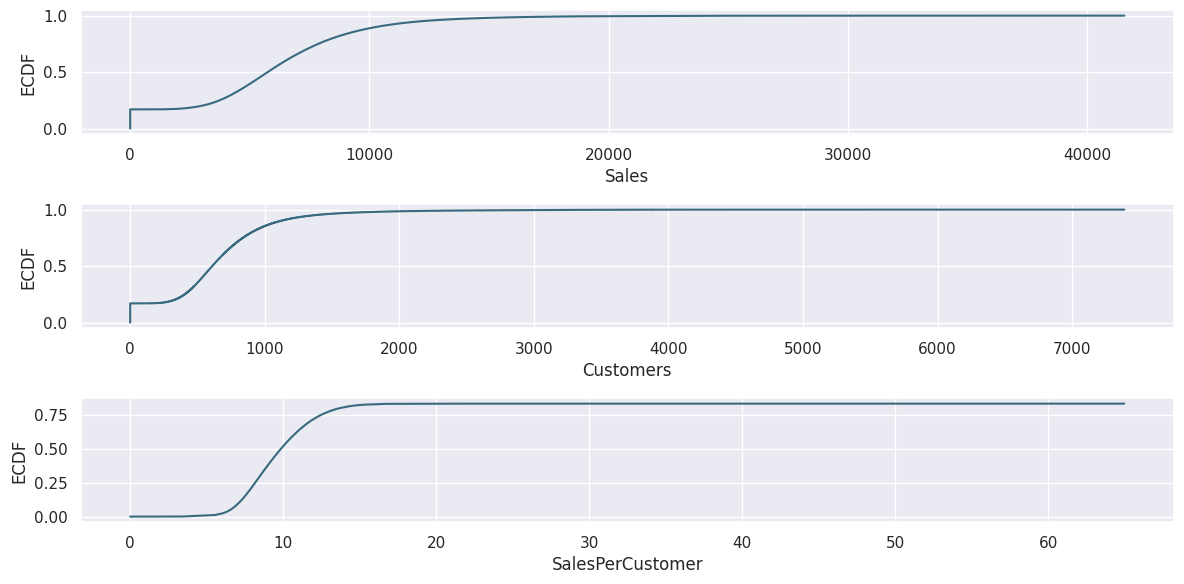

In [11]:
sns.set(style="darkgrid")
c = '#386B7F' # basic color for plots
plt.figure(figsize = (12,6))

plt.subplot(311)
cdf = ECDF(train["Sales"])
plt.plot(cdf.x, cdf.y, label = "statsmodel", color = c)
plt.xlabel("Sales")
plt.ylabel("ECDF")

plt.subplot(312)
cdf = ECDF ( train["Customers"])
plt.plot(cdf.x, cdf.y, label = "statmodel", color = c)
plt.xlabel("Customers")
plt.ylabel("ECDF")

plt.subplot(313)
cdf = ECDF(train["SalesPerCustomer"])
plt.plot(cdf.x, cdf.y, label = "statmodel", color = c)
plt.xlabel("SalesPerCustomer")
plt.ylabel("ECDF")

plt.tight_layout()
plt.show()

Top curve:
Most observations are below around 10,000, but the curve continues slowly up to about 40,000. This means there are some very large values creating a long right tail.

Middle curve:
The curve rises very quickly before about 1,000–1,500. So most values are small, but a few observations extend up to around 7,000+.

Bottom curve:
Most values are concentrated around 8–15 SalesPerCustomer. After around 20, the curve becomes almost flat, meaning only a few extreme high values exist.

About 20% observations has zero amount of sales or customers that we need to deal with and almost 80% of time daily amount of sales was less than 1000.

So what about zero sales, is it for zero customer or store was closed?


#####Missing values
closed store and zero sales stores


In [12]:
train[(train.Open == 0) & (train.Sales == 0) ].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekofYear,SalesPerCustomer
Date,,,,,,,,,,,,,
2015-07-31,292,5,0,0,0,1,0,1,2015,7,31,31,NaN
2015-07-31,876,5,0,0,0,1,0,1,2015,7,31,31,NaN
2015-07-30,292,4,0,0,0,1,0,1,2015,7,30,31,NaN
2015-07-30,876,4,0,0,0,1,0,1,2015,7,30,31,NaN
2015-07-29,292,3,0,0,0,1,0,1,2015,7,29,31,NaN


In [13]:
#How many Zero sales when the store was closed.
store_close = train[(train.Open == 0) & (train.Sales == 0) ]
len(store_close)

172817

There're 172817 closed stores in the data. It is about 10% of the total amount(1017209)of observations. To avoid any biased forecasts we will drop these values.

In [14]:
#How many Zero sales when the store was open
zero_sales = train[(train.Open == 1) & (train.Sales == 0) ]
print(zero_sales.shape)
zero_sales.head(5)

(54, 13)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekofYear,SalesPerCustomer
Date,,,,,,,,,,,,,
2015-05-15,971,5,0,0,1,0,0,1,2015,5,15,20,NaN
2015-03-26,674,4,0,0,1,0,0,0,2015,3,26,13,NaN
2015-02-05,699,4,0,0,1,1,0,0,2015,2,5,6,NaN
2014-10-01,708,3,0,0,1,1,0,0,2014,10,1,40,NaN
2014-09-22,357,1,0,0,1,0,0,0,2014,9,22,39,NaN


#####Store

Store was opened but No sales for 54 working days.
We can assume there are external factors involved. We need to find out.


In [15]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


* Store: a unique Id for each store
* StoreType: differentiates between 4 different store models: a, b, c, d
* Assortment: describes an assortment level: a = basic, b = extra, c = extended
* CompetitionDistance: distance in meters to the nearest competitor store
* CompetitionOpenSince[Month/Year]: gives the approximate year and month of the time the nearest competitor was opened
* Promo2: Promo2 is a continuing a promotion for some stores: 0 = store is not participating, 1 = store is participating
* Promo2Since[Year/Week]: describes the year and calendar week when the store started participating in Promo2
* PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [16]:
#missing value in store
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


We have few variables with missing values that we need to deal with. Let's start with the CompetitionDistance.

In [17]:
#missing value in competitionDistance
store[pd.isnull(store["CompetitionDistance"])]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Apperently this information is simply missing from the data. No particular pattern observed. In this case, it makes a complete sense to replace NaN with the median values (which is twice less that the average).

In [18]:
# fill NaN with a median value (skewed distribuion)
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace = True)

Continuing further with missing data. What about Promo2SinceWeek? May it be that we observe unsusual data points?

In [19]:
# no promo = no information about the promo?
## Missing Promo2SinceWeek means the store is not participating in Promo2
promo_check = store[pd.isnull(store.Promo2SinceWeek)]
promo_check[promo_check.Promo2 != 0].shape

(0, 10)

No, if there's no Promo2 then there's no information about it. We can replace these values by zeros. The same goes for tha variables deducted from the competition, CompetitionOpenSinceMonth and CompetitionOpenSinceYear.

In [20]:
# replace NA's by 0
store.fillna(0, inplace = True)

In [21]:
#missing value in store
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,0
CompetitionOpenSinceMonth,0
CompetitionOpenSinceYear,0
Promo2,0
Promo2SinceWeek,0
Promo2SinceYear,0
PromoInterval,0


#####Train and store data join

In [22]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts. So open store and sales on values ")
train = train[(train["Open"] !=  0) & (train['Sales'] != 0)] # store = open, sales = on

print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts. So open store and sales on values 
In total:  (844338, 13)


In [23]:
print("Joining train set with an additional store information.")

# by specifying inner join we make sure that only those observations
# that are present in both train and store sets are merged together
train_store = pd.merge(train, store, how = 'inner', on = 'Store')

print("In total: ", train_store.shape)
train_store.head()

Joining train set with an additional store information.
In total:  (844338, 22)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,...,SalesPerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,5263,555,1,1,0,1,2015,7,...,9.482883,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,6064,625,1,1,0,1,2015,7,...,9.702400,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,8314,821,1,1,0,1,2015,7,...,10.126675,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,13995,1498,1,1,0,1,2015,7,...,9.342457,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,4822,559,1,1,0,1,2015,7,...,8.626118,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


#####Store types

In this section we will closely look at different levels of StoreType and how the main metric Sales is distributed among them.

In [24]:
train_store.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457042.0,6925.697986,3277.351589,46.0,4695.25,6285.0,8406.00,41551.0
b,15560.0,10233.380141,5155.729868,1252.0,6345.75,9130.0,13184.25,38722.0
c,112968.0,6933.126425,2896.958579,133.0,4916.00,6408.0,8349.25,31448.0
d,258768.0,6822.300064,2556.401455,538.0,5050.00,6395.0,8123.25,38037.0


StoreType B has the highest average of Sales among all others, however we have much less data for it. So let's print an overall sum of Sales and Customers to see which StoreType is the most selling and crowded one:

In [25]:
train_store.groupby('StoreType')[['Customers','Sales']].sum()

,Customers,Sales
StoreType,,
a,363541431,3165334859
b,31465616,159231395
c,92129705,783221426
d,156904995,1765392943


Clearly stores of type A. StoreType D goes on the second place in both Sales and Customers.

What about date periods? Seaborn's facet grid is the best tool for this task:

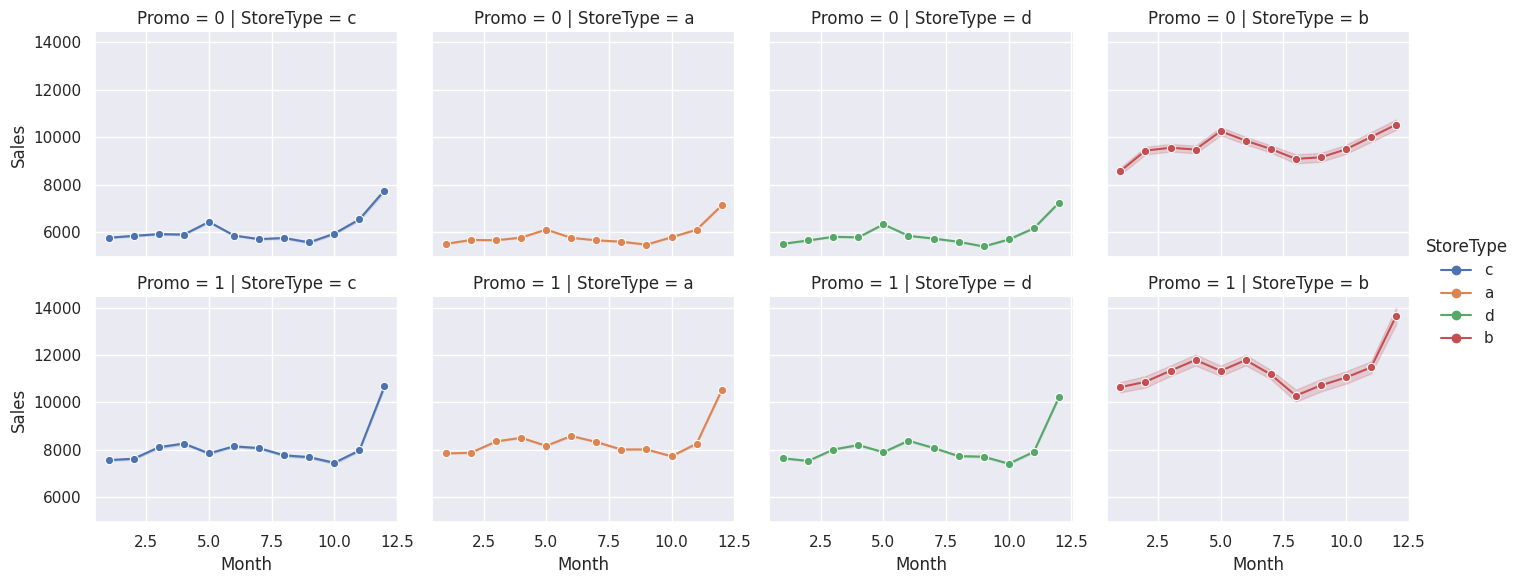

In [26]:
# sales trends promo and storetype vs sales

g = sns.relplot(
    data=train_store,
    x="Month",
    y="Sales",
    row="Promo",
    col="StoreType",
    hue="StoreType",
    kind="line",
    estimator="mean",
    errorbar="se",
    marker="o",
    height=3,
    aspect=1.2,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Month", "Sales")
g.set_titles("Promo = {row_name} | StoreType = {col_name}")
plt.show()

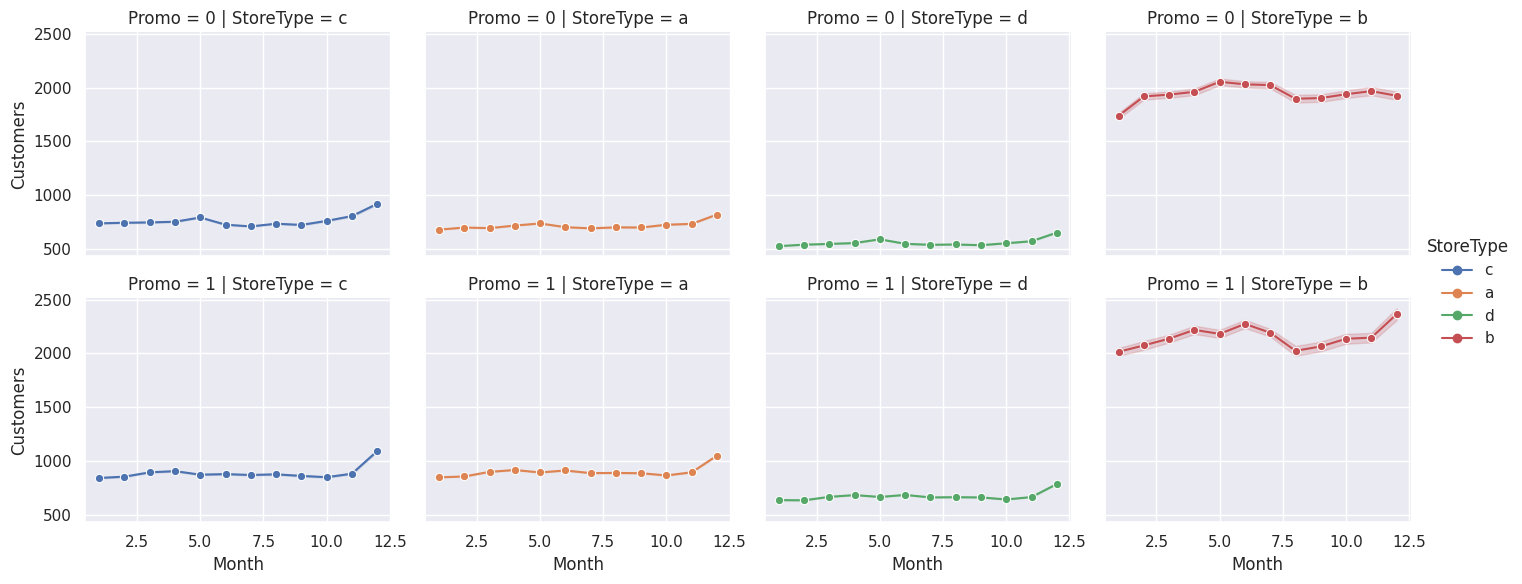

In [27]:
#sales trends promo and storetype vs customers

g = sns.relplot(
    data=train_store,
    x="Month",
    y="Customers",
    row="Promo",
    col="StoreType",
    hue="StoreType",
    kind="line",
    estimator="mean",
    errorbar="se",
    marker="o",
    height=3,
    aspect=1.2,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Month", "Customers")
g.set_titles("Promo = {row_name} | StoreType = {col_name}")
plt.show()

All store types follow the same trend but at different scales depending on the presence of the (first) promotion Promo and StoreType itself (case for B).

**Already at this point, we can see that Sales escalate towards Christmas holidays. But we'll talk about seasonalities and trends later in the Time Series Analysis section.**

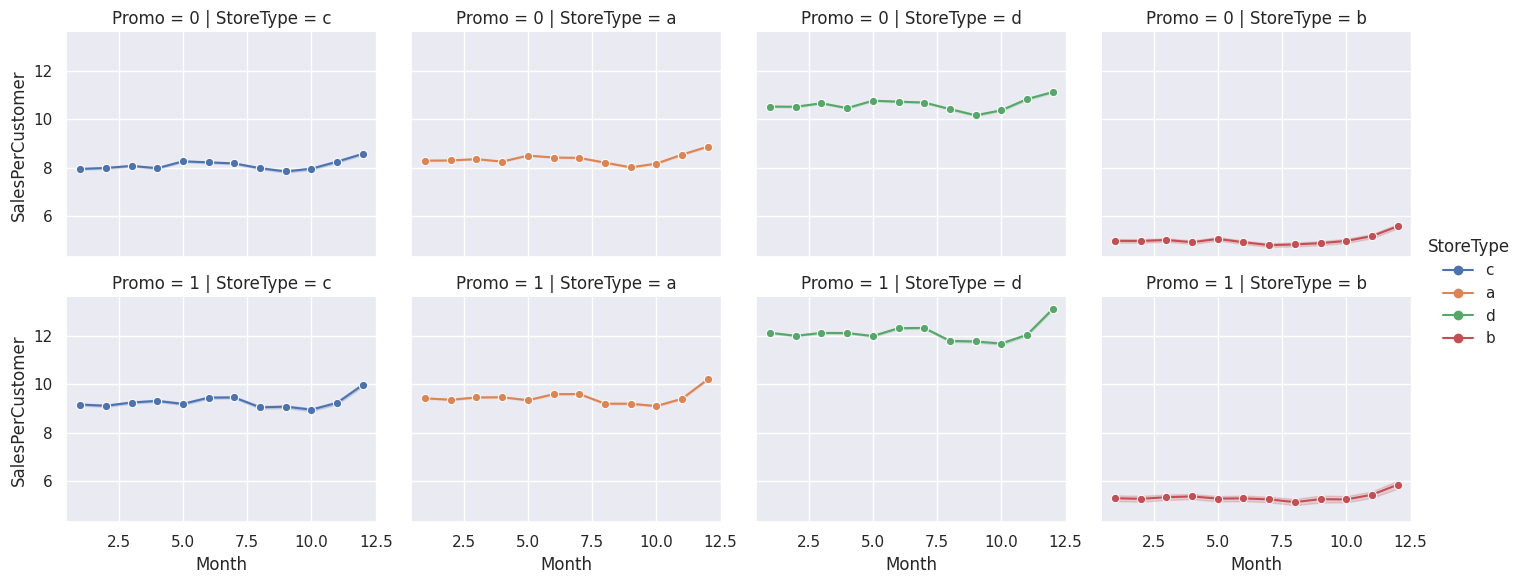

In [28]:
# sale per customer trends
g = sns.relplot(
    data=train_store, x="Month", y="SalesPerCustomer",
    row="Promo", #per promo in the store in rows
    col="StoreType", #per storetype in cols
    hue="StoreType",
    kind="line",
    estimator="mean",
    #errorbar="se",
    marker="o",
    height=3,
    aspect=1.2,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Month", "SalesPerCustomer")
g.set_titles("Promo = {row_name} | StoreType = {col_name}")
plt.show()

Eventhough the plots above showed StoreType B as the most selling and performant one, in reality it is not true. The highest SalePerCustomer amount is observed at the StoreType D, about 12€ with Promo and 10€ without. As for StoreType A and C it is about 9€.

Low SalePerCustomer amount for StoreType B describes its Buyer Cart: there are a lot of people who shop essentially for "small" things (or in a little quantity). Plus we saw that overall this StoreType generated the least amount of sales and customers over the period

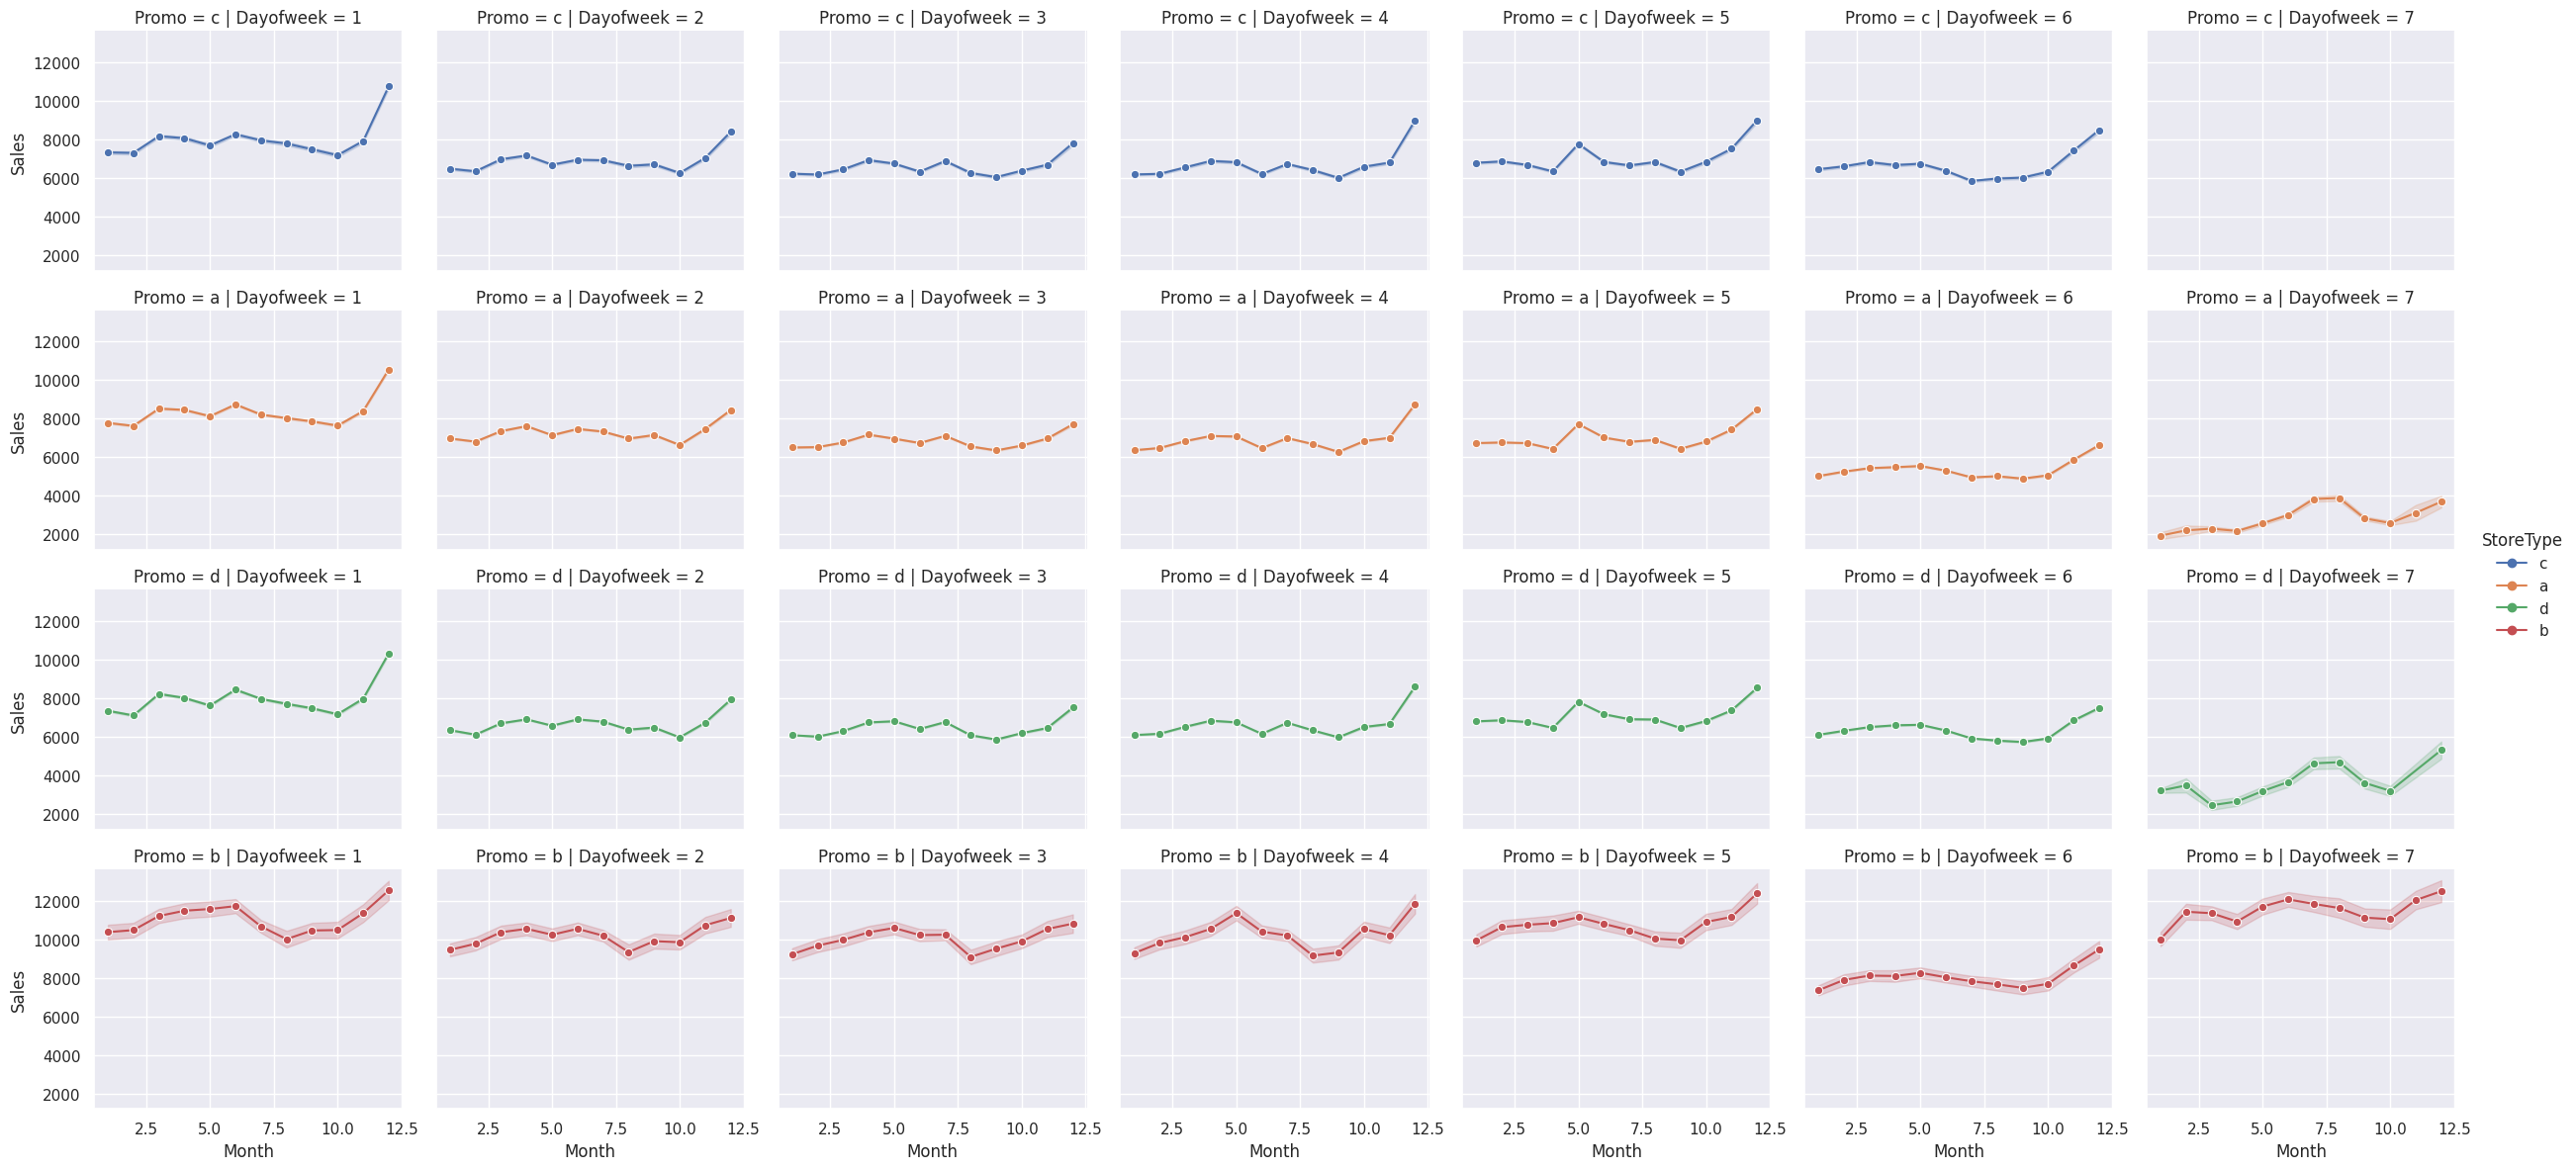

In [29]:
#Sales trends for week days

g = sns.relplot(
    data=train_store, x="Month", y="Sales",
    row="StoreType", #per storetype in rows
    col="DayOfWeek", #per day
    hue="StoreType",
    kind="line",
    estimator="mean",
    errorbar="se",
    marker="o",
    height=3,
    aspect=1.2,
    facet_kws={"sharey": True}
)

g.set_axis_labels("Month", "Sales")
g.set_titles("Promo = {row_name} | Dayofweek = {col_name}")
plt.show()

We see that stores of StoreType C are all closed on Sundays, whereas others are most of the time opened. Interestingly enough, stores of StoreType D are closed on Sundays only from October to December.

**Bt the way what are the stores which are opened on Sundays?**

In [30]:
# Finding stores that are open on Sundays
sunday_open_stores = train_store.loc[
    (train_store["Open"] == 1) &
    (train_store["DayOfWeek"] == 7),
    "Store"
].unique()

print(sunday_open_stores)
print ("how many stores open on sunday? answer = ", len(sunday_open_stores))

[  85  122  209  259  262  274  299  310  335  353  423  433  453  494
  512  524  530  562  578  676  682  732  733  769  863  867  931  948
 1045 1081 1097 1099  877]
how many stores open on sunday? answer =  33


#####Correlation Analysis

We are finished with adding new variables to the data, so now we can check the overall correlations by plotting the seaborn heatmap:

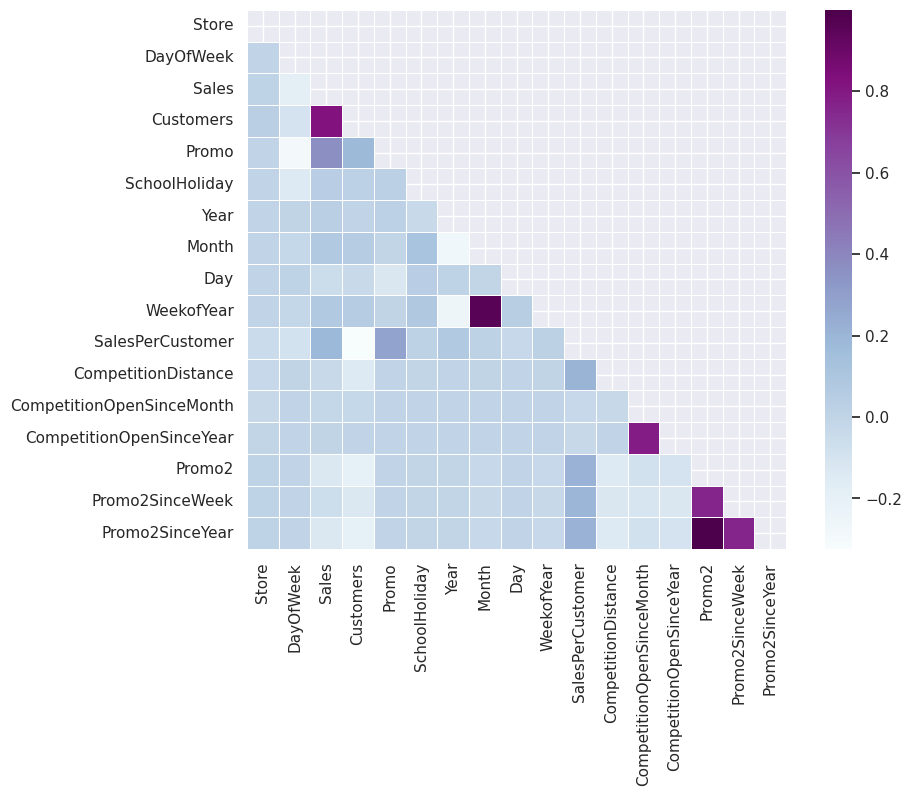

In [31]:
# Compute the correlation matrix
# exclude 'Open' variable
corr_all = train_store.drop('Open', axis = 1).corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.zeros_like(corr_all, dtype = np.bool_)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize = (10, 7))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_all, mask = mask,
            square = True, linewidths = .5, ax = ax, cmap = "BuPu")
plt.show()

As mentioned before, we have a strong positive correlation between the amount of Sales and Customers of a store. We can also observe a positive correlation between the fact that the store had a running promotion (Promo equal to 1) and amount of Customers.

However, as soon as the store continues a consecutive promotion (Promo2 equal to 1) the number of Customers and Sales seems to stay the same or even decrease, which is described by the pale negative correlation on the heatmap. The same negative correlation is observed between the presence of the promotion in the store and the day of a week.

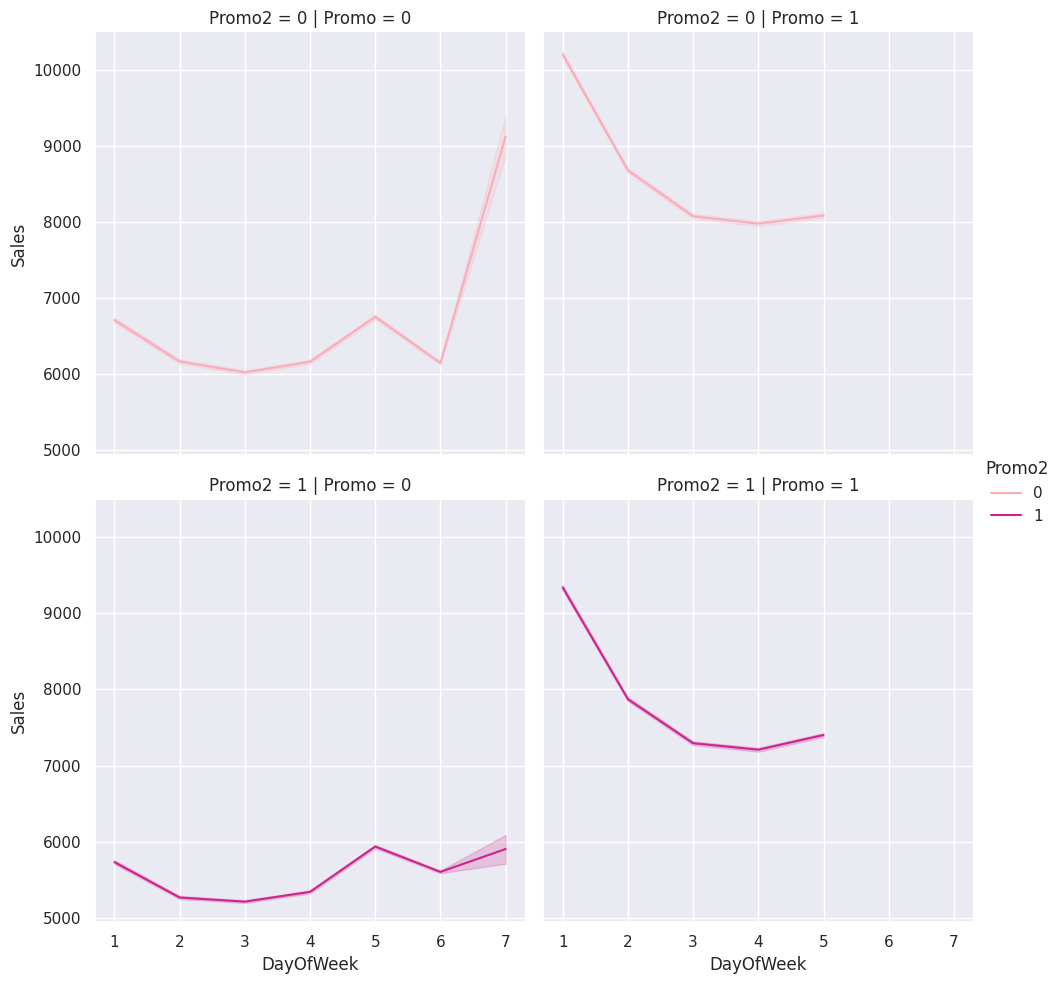

In [32]:
# sale per customer trends
sns.relplot(data = train_store, x = 'DayOfWeek', y = "Sales",
               col = 'Promo',
               row = 'Promo2',
               kind="line",
               estimator="mean",
               hue = 'Promo2',
               palette = 'RdPu')

There are several things here:

* In case of no promotion, both Promo and Promo2 are equal to 0, Sales tend to peak on Sunday (!). Though we should note that StoreType C doesn't work on Sundays. So it is mainly data from StoreType A, B and D.

* On the contrary, stores that run the promotion tend to make most of the Sales on Monday. This fact could be a good indicator for Rossmann marketing campaigns. The same trend follow the stores which have both promotion at the same time (Promo and Promo2 are equal to 1).
* Promo2 alone doesn't seem to be correlated to any significant change in the Sales amount. This can be also prooved by the blue pale area on the heatmap above.

##### Conclusion of EDA

* The most selling and crowded StoreType is A.

* The best "Sale per Customer" StoreType D indicates to the higher Buyer Cart. We could also assume that the stores of this types are situated in the rural areas, so that customers prefer buying more but less often.

* Low SalePerCustomer amount for StoreType B indicates to the possible fact that people shop there essentially for small things. Which can also indicate to the label of this store type - "urban" - as it's more accessible for public, and customers don't mind shopping there from time to time during a week.

* Customers tends to buy more on Mondays when there's one promotion running (Promo) and on Sundays when there is no promotion at all (both Promo and Promo1 are equal to 0).

 * Promo2 alone doesn't seem to be correlated to any significant change in the Sales amount.

#####timeseriesAnalysis

In this section, we will analyse time series data: its trends, sesonalities and autocorrelation. Usually at the end of the analysis, we are able to develop a seasonal ARIMA (Autoregression Integrated Moving Average) model but it won't be our main focus today. Instead, we try to understand the data, and only later come up with the forecasts using Prophet methodology.

<Axes: xlabel='Date'>

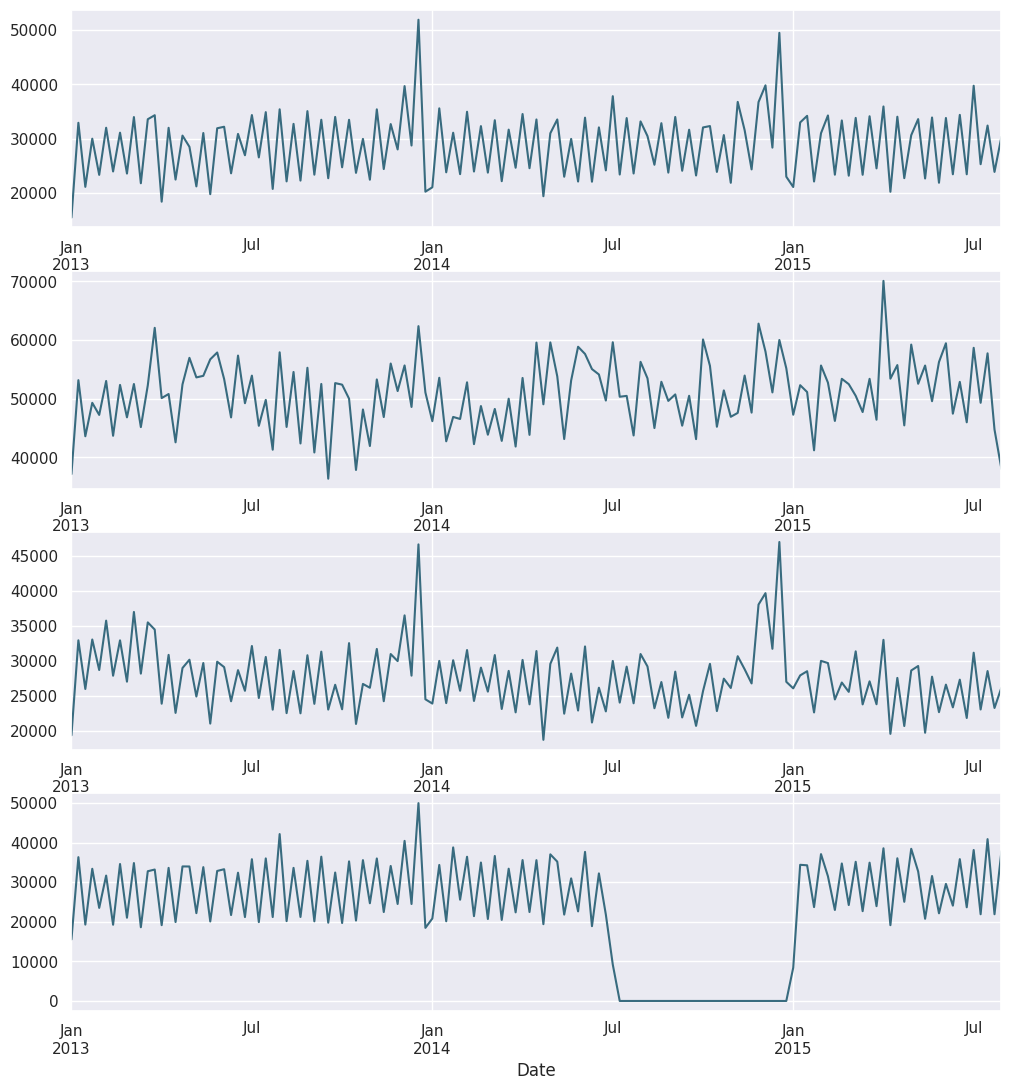

In [33]:
# preparation: input should be float type
train['Sales'] = train['Sales'] * 1.0

# store types
sales_a = train[train.Store == 2]['Sales']
sales_b = train[train.Store == 85]['Sales'].sort_index(ascending = True) # solve the reverse order
sales_c = train[train.Store == 1]['Sales']
sales_d = train[train.Store == 13]['Sales']

f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize = (12, 13))

# store types
sales_a.resample('W').sum().plot(color = c, ax = ax1)
sales_b.resample('W').sum().plot(color = c, ax = ax2)
sales_c.resample('W').sum().plot(color = c, ax = ax3)
sales_d.resample('W').sum().plot(color = c, ax = ax4)

####Time Series Analysis and Forecasting with Prophet

**Forecasting for the next 6 weeks for the first store**

The Core Data Science team at Facebook recently published a new procedure for forecasting time series data called Prophet. It is based on an additive model where non-linear trends are fit with yearly and weekly seasonality, plus holidays. It enables performing automated forecasting which are already implemented in R at scale in Python 3.

In [43]:
# importing data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kaggle_rossman/train.csv",low_memory = False)

# remove closed stores and those with no sales
df = df[(df["Open"] != 0) & (df['Sales'] != 0)]

# sales for the store number 1 (StoreType C)
sales = df[df.Store == 1].loc[:, ['Date', 'Sales']]

# reverse to the order: from 2013 to 2015
sales = sales.sort_index(ascending = False)

# to datetime64
sales['Date'] = pd.DatetimeIndex(sales['Date'])
sales.dtypes

,0
Date,datetime64[ns]
Sales,int64


In [44]:
# from the prophet documentation every variables should have specific names
sales = sales.rename(columns = {'Date': 'ds',
                                'Sales': 'y'})
sales.head(5)

,ds,y
1014980,2013-01-02,5530
1013865,2013-01-03,4327
1012750,2013-01-04,4486
1011635,2013-01-05,4997
1009405,2013-01-07,7176


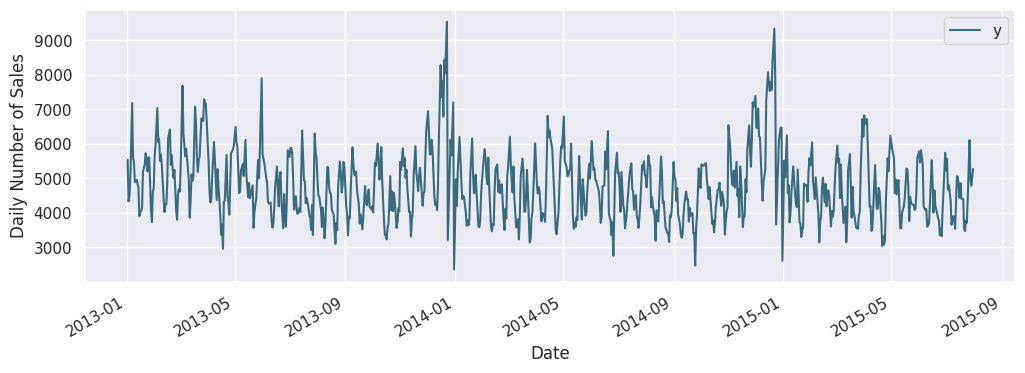

In [45]:
# plot daily sales
ax = sales.set_index('ds').plot(figsize = (12, 4), color = c)
ax.set_ylabel('Daily Number of Sales')
ax.set_xlabel('Date')
plt.show()

##### Modeling holidays

Prophet also allows to model for holidays, and that's what we do here.

The StateHoliday variable in the dataset indicates a state holiday, at which all stores are normally closed. There are also school holidays in the dataset at which ceratin stores are also closing their doors.

In [46]:
# create holidays dataframe
state_dates = df[(df.StateHoliday == 'a') | (df.StateHoliday == 'b') & (df.StateHoliday == 'c')].loc[:, 'Date'].values
school_dates = df[df.SchoolHoliday == 1].loc[:, 'Date'].values

state = pd.DataFrame({'holiday': 'state_holiday',
                      'ds': pd.to_datetime(state_dates)})
school = pd.DataFrame({'holiday': 'school_holiday',
                      'ds': pd.to_datetime(school_dates)})

holidays = pd.concat((state, school))
holidays.head()

,holiday,ds
0,state_holiday,2015-06-04
1,state_holiday,2015-06-04
2,state_holiday,2015-06-04
3,state_holiday,2015-06-04
4,state_holiday,2015-06-04


In [47]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = Prophet(interval_width = 0.95,
                   holidays = holidays)
my_model.fit(sales)

# dataframe that extends into future 6 weeks
future_dates = my_model.make_future_dataframe(periods = 6*7)

print("First week to forecast.")
future_dates.tail(7)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


First week to forecast.


,ds
816,2015-09-05
817,2015-09-06
818,2015-09-07
819,2015-09-08
820,2015-09-09
821,2015-09-10
822,2015-09-11


In [39]:
# predictions
forecast = my_model.predict(future_dates)

# preditions for last week
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
816,2015-09-05,4092.607883,2510.538135,5604.900888
817,2015-09-06,4087.408629,2413.927046,5734.123389
818,2015-09-07,4162.124519,2550.809743,5797.584304
819,2015-09-08,3664.553166,2109.357612,5334.987625
820,2015-09-09,3551.373108,1962.690854,5147.594530
821,2015-09-10,3462.863628,1887.324575,5096.779944
822,2015-09-11,3717.513944,2066.831272,5390.041677


The forecast object here is a new dataframe that includes a column yhat with the forecast, as well as columns for components and uncertainty intervals.

In [40]:
fc = forecast[['ds', 'yhat']].rename(columns = {'Date': 'ds', 'Forecast': 'yhat'})

Prophet plots the observed values of our time series (the black dots), the forecasted values (blue line) and the uncertainty intervals of our forecasts (the blue shaded regions).

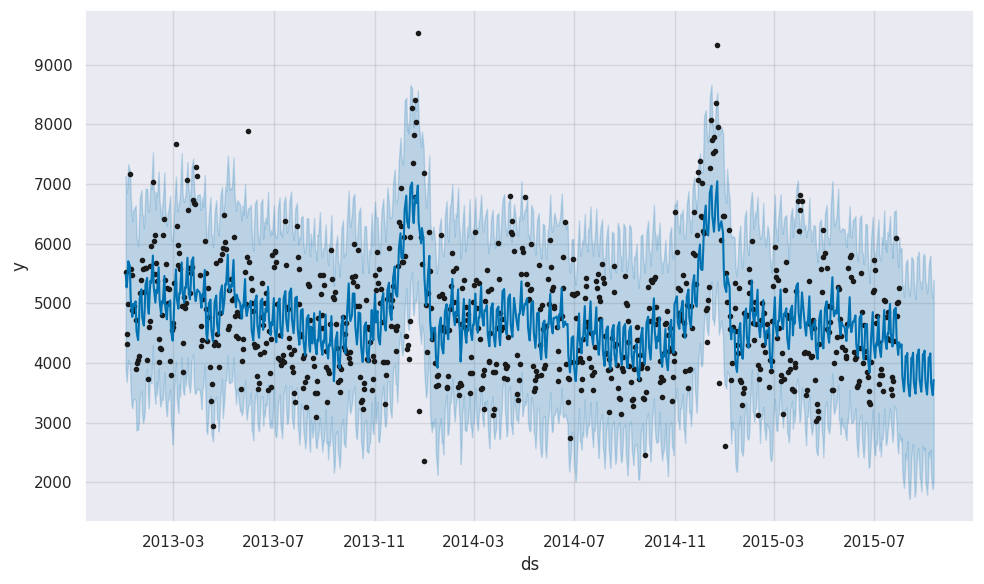

In [41]:
# visualizing predicions
my_model.plot(forecast);

As we see Prophet catches the trends and most of the time gets future values right.

One other particularly strong feature of Prophet is its ability to return the components of our forecasts. This can help reveal how daily, weekly and yearly patterns of the time series plus manyally included holidayes contribute to the overall forecasted values:

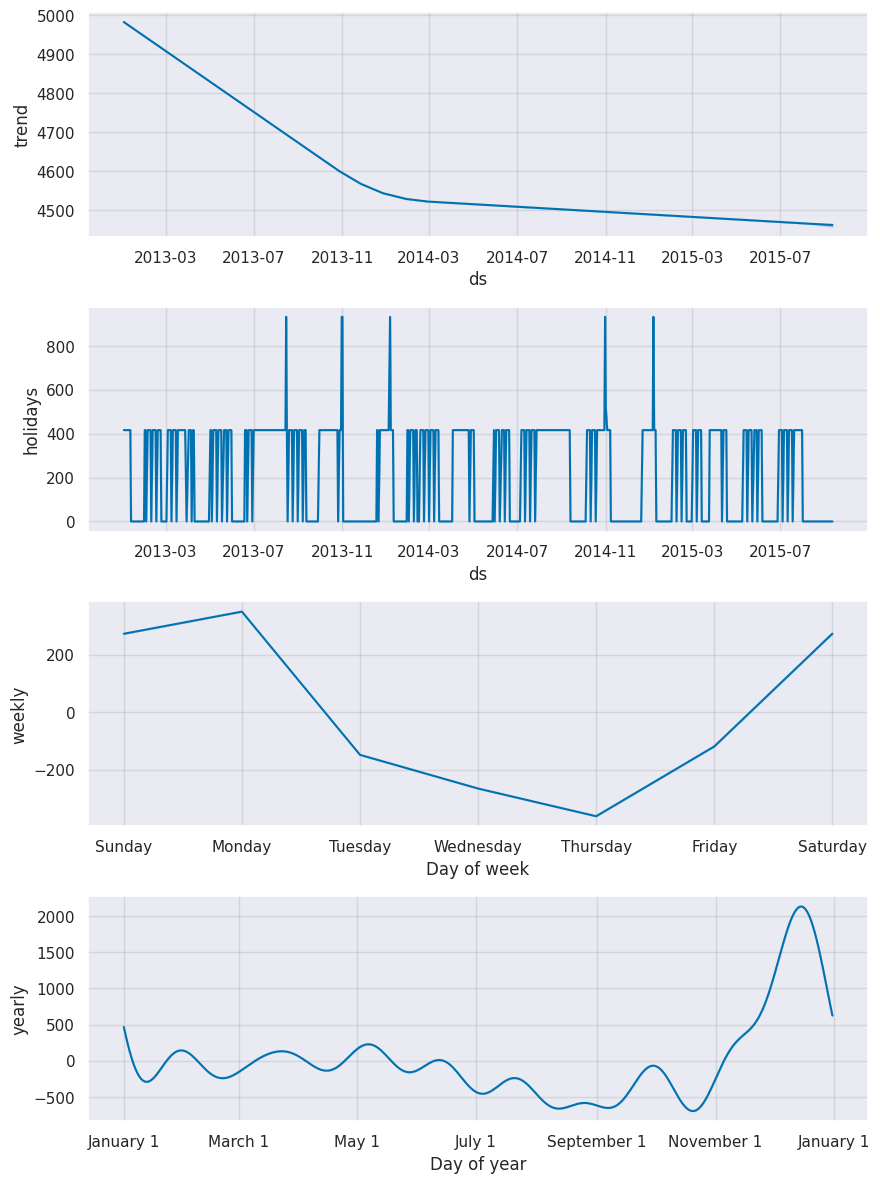

In [42]:
my_model.plot_components(forecast);

The first plot shows that the monthly sales of store number 1 has been linearly decreasing over time and the second shows the holiays gaps included in the model. The third plot highlights the fact that the weekly volume of last week sales peaks towards the Monday of the next week, while the forth plot shows that the most buzy season occurs during the Christmas holidays.